# Baseline Models — Linear Regression & Ridge Regression

These simple models establish a performance floor that more complex models must beat.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [11]:
df = pd.read_csv("./data/final_merged_data_rain_plus_crop_yield.csv")
print(f"Loaded: {df.shape}")
df.head(3)

Loaded: (19439, 23)


,District,Year,Crop,Season,Area,Production,Yield,Yield_Lag1,Yield_Lag2,Yield_3yr_Avg,...,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
0,ahilyanagar,1998,Arhar_Tur,Kharif,18800.0,9700.0,0.515957,0.357955,0.357955,0.515957,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
1,ahilyanagar,1998,Bajra,Kharif,302400.0,243900.0,0.806548,0.557461,0.557461,0.806548,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
2,ahilyanagar,1998,Castor_seed,Kharif,400.0,100.0,0.250000,0.250000,0.250000,0.250000,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3


## 1. Feature Preparation

For baseline models, we use **all features except target leakers** (Production, Area) and keep lag features.

In [12]:
# Features: everything except Yield, Production, Area
X = df.drop(columns=["Yield", "Production", "Area"])
y = np.log1p(df["Yield"])

X = pd.get_dummies(X, columns=["District", "Crop", "Season"])

print(f"Features: {X.shape[1]} columns")
print(f"Target: {len(y)} samples")
X.head(3)

Features: 81 columns
Target: 19439 samples


,Year,Yield_Lag1,Yield_Lag2,Yield_3yr_Avg,Yield_3yr_Std,june_normal_rainfall,june_actual_rainfall,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,...,Crop_Small_millets,Crop_Soyabean,Crop_Sugarcane,Crop_Sunflower,Crop_Urad,Crop_Wheat,Crop_other_oilseeds,Season_Kharif,Season_Rabi,Season_Summer
0,1998,0.357955,0.357955,0.515957,0.0,108.2,137.0,126.6,97.5,133.5,...,False,False,False,False,False,False,False,True,False,False
1,1998,0.557461,0.557461,0.806548,0.0,108.2,137.0,126.6,97.5,133.5,...,False,False,False,False,False,False,False,True,False,False
2,1998,0.250000,0.250000,0.250000,0.0,108.2,137.0,126.6,97.5,133.5,...,False,False,False,False,False,False,False,True,False,False


## 2. Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 15551 samples
Test:  3888 samples


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3. Linear Regression

In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
lr_preds_log = lr_model.predict(X_test)

# Convert back
lr_preds = np.expm1(lr_preds_log)
y_test_actual = np.expm1(y_test)

# Clip extreme values
lr_preds = np.clip(lr_preds, 0, 5)

# Metrics
lr_r2 = r2_score(y_test_actual, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test_actual, lr_preds))
lr_mae = mean_absolute_error(y_test_actual, lr_preds)

print("Linear Regression Results:")
print(f"R²:   {lr_r2:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE:  {lr_mae:.4f}")

Linear Regression Results:
R²:   0.1135
RMSE: 3.3626
MAE:  0.4317


## 4. Ridge Regression (L2 Regularization)

In [16]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

ridge_preds_log = ridge_model.predict(X_test)

ridge_preds = np.expm1(ridge_preds_log)
ridge_preds = np.clip(ridge_preds, 0, 5)

ridge_r2 = r2_score(y_test_actual, ridge_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_test_actual, ridge_preds))
ridge_mae = mean_absolute_error(y_test_actual, ridge_preds)

print("\nRidge Regression Results:")
print(f"R²:   {ridge_r2:.4f}")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"MAE:  {ridge_mae:.4f}")


Ridge Regression Results:
R²:   0.1135
RMSE: 3.3626
MAE:  0.4317


## 5. Model Comparison

In [17]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'R²': [lr_r2, ridge_r2],
    'RMSE': [lr_rmse, ridge_rmse],
    'MAE': [lr_mae, ridge_mae]
})
print(results.to_string(index=False))

            Model       R²     RMSE      MAE
Linear Regression 0.113545 3.362634 0.431739
 Ridge Regression 0.113545 3.362634 0.431740


## 6. Predicted vs Actual — Scatter Plots

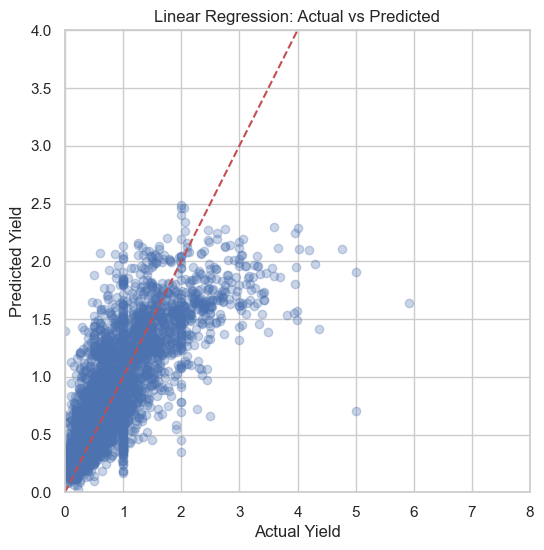

In [23]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_actual, lr_preds, alpha=0.3)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.ylim(0, 4)
plt.xlim(0, 8)
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

## 7. Ridge Plots

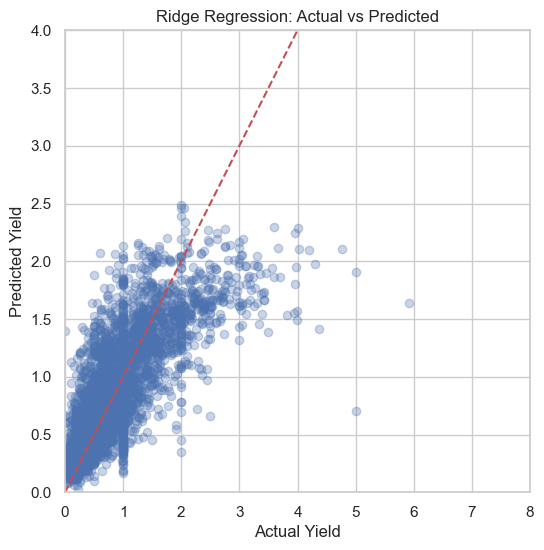

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_actual, ridge_preds, alpha=0.3)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylim(0, 4)
plt.xlim(0, 8)
plt.ylabel("Predicted Yield")
plt.title("Ridge Regression: Actual vs Predicted")

plt.show()

## Summary

Baseline models give us a performance floor. The R² and RMSE values here will be compared against Random Forest and Gradient Boosting in the next notebook.